# Pneumonia Detection — Transfer Learning (MobileNetV2)
Two-phase strategy: **Phase 1** frozen base → **Phase 2** fine-tune top layers.

## 1. Imports & GPU Check

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report

sys.path.insert(0, os.path.abspath('..'))

gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus if gpus else 'None — running on CPU')

I0000 00:00:1773812545.492134  276175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773812545.496961  276175 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773812545.665526  276175 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773812550.823913  276175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

GPUs: None — running on CPU


E0000 00:00:1773812552.022811  276175 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773812552.029438  276410 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773812552.121698  276175 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Configuration

In [2]:
DATA_DIR   = '../data/raw/chest_xray'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
VAL_DIR    = os.path.join(DATA_DIR, 'val')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
MODEL_PATH = '../models/pneumonia_mobilenetv2.keras'
PLOTS_DIR  = '../results/plots'

os.makedirs('../models', exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

IMAGE_SIZE         = (224, 224)
BATCH_SIZE         = 32
CLASSES            = ['NORMAL', 'PNEUMONIA']
TL_EPOCHS_FROZEN   = 10     # Phase 1: head warm-up only
TL_EPOCHS_FINETUNE = 30     # Phase 2: fine-tune top layers
TL_LR_FROZEN       = 1e-3   # Higher LR — base is frozen
TL_LR_FINETUNE     = 1e-5   # Very low LR — preserve pretrained weights
TL_UNFREEZE_FROM   = 100    # Unfreeze MobileNetV2 layers from this index onward

print('Dataset folders:', os.listdir(DATA_DIR))

Dataset folders: ['.DS_Store', 'val', 'train', 'test']


## 3. Data Generators

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
eval_datagen = ImageDataGenerator(rescale=1./255)

common = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
              color_mode='grayscale', class_mode='binary')

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, shuffle=True,  **common)
val_gen   = eval_datagen.flow_from_directory(VAL_DIR,   shuffle=False, **common)
test_gen  = eval_datagen.flow_from_directory(TEST_DIR,  shuffle=False, **common)

print(f'Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}')
print(f'Class indices: {train_gen.class_indices}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train: 5216 | Val: 16 | Test: 624
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 4. Model — MobileNetV2 + Custom Head
Grayscale images are repeated across 3 channels so MobileNetV2 (pretrained on RGB ImageNet) can accept them.

In [4]:
def build_transfer_model(trainable_base=False):
    inputs = layers.Input(shape=(*IMAGE_SIZE, 1))

    # Grayscale → RGB: repeat channel 3 times
    x = layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1), name='gray_to_rgb')(inputs)

    # MobileNetV2 pretrained on ImageNet
    base = tf.keras.applications.MobileNetV2(
        input_shape=(*IMAGE_SIZE, 3), include_top=False, weights='imagenet'
    )

    if trainable_base:
        # Phase 2: freeze early layers, unfreeze top layers
        for layer in base.layers[:TL_UNFREEZE_FROM]:
            layer.trainable = False
        for layer in base.layers[TL_UNFREEZE_FROM:]:
            layer.trainable = True
    else:
        base.trainable = False  # Phase 1: entire base frozen

    x = base(x, training=trainable_base)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name='pneumonia_mobilenetv2')


def make_callbacks(path):
    return [
     
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            path, monitor='val_accuracy', save_best_only=True, verbose=1
        ),
    ]

## 5. Phase 1 — Train Head Only (Frozen Base)

In [5]:
model = build_transfer_model(trainable_base=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(TL_LR_FROZEN),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

train_gen.reset(); val_gen.reset()
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TL_EPOCHS_FROZEN,
    callbacks=make_callbacks(MODEL_PATH)
)

Model: "pneumonia_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gray_to_rgb (Lambda)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10


I0000 00:00:1773812558.081554  276175 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.8398 - loss: 0.3629
Epoch 1: val_accuracy improved from None to 0.93750, saving model to ../models/pneumonia_mobilenetv2.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.8963 - loss: 0.2442 - val_accuracy: 0.9375 - val_loss: 0.2381 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.9367 - loss: 0.1643
Epoch 2: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 196s 969ms/step - accuracy: 0.9354 - loss: 0.1681 - val_accuracy: 0.8125 - val_loss: 0.3252 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.9399 - loss: 0.1526
Epoch 3: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 159s 973ms/step - accuracy: 0.9413 - loss: 0.1486 - val_accuracy: 0.8750 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.9525 - loss: 0.1239
Epoch 4: ReduceLRO

## 6. Phase 2 — Fine-Tune Top Layers (Low LR)

In [6]:
# Rebuild with top layers unfrozen, carry over Phase 1 weights
model_ft = build_transfer_model(trainable_base=True)
model_ft.set_weights(model.get_weights())

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(TL_LR_FINETUNE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_gen.reset(); val_gen.reset()
history_p2 = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TL_EPOCHS_FINETUNE,
    callbacks=make_callbacks(MODEL_PATH)
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8680 - loss: 0.3408
Epoch 1: val_accuracy improved from None to 0.68750, saving model to ../models/pneumonia_mobilenetv2.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.8963 - loss: 0.2675 - val_accuracy: 0.6875 - val_loss: 0.8269 - learning_rate: 1.0000e-05
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9271 - loss: 0.1799
Epoch 2: val_accuracy did not improve from 0.68750
163/163 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.9329 - loss: 0.1730 - val_accuracy: 0.6250 - val_loss: 1.0533 - learning_rate: 1.0000e-05
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9379 - loss: 0.1691
Epoch 3: val_accuracy did not improve from 0.68750
163/163 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9448 - loss: 0.1490 - val_accuracy: 0.6250 - val_loss: 1.2355 - learning_rate: 1.0000e-05
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9470 - loss: 0.1403
Epoch 4: Redu

## 7. Combined Training Curves (Phase 1 + Phase 2)

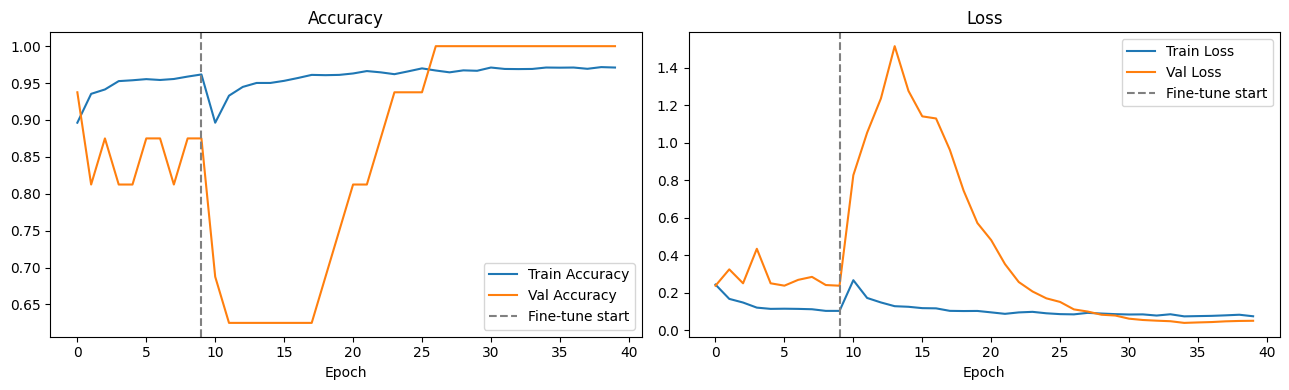

In [7]:
combined   = {k: history_p1.history[k] + history_p2.history[k] for k in history_p1.history}
phase1_end = len(history_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (tk, vk), title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(combined[tk], label=f'Train {title}')
    ax.plot(combined[vk], label=f'Val {title}')
    ax.axvline(phase1_end - 1, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'tl_training_curves.png'), dpi=150)
plt.show()

## 8. Evaluate on Test Set

In [8]:
test_gen.reset()
tl_loss, tl_acc = model_ft.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {tl_loss:.4f}')
print(f'Test Accuracy : {tl_acc:.4f}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 780ms/step - accuracy: 0.8830 - loss: 0.3136

Test Loss     : 0.3136
Test Accuracy : 0.8830


## 9. Confusion Matrix, Precision, Recall & F1-Score

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 998ms/step

── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL       0.91      0.76      0.83       234
   PNEUMONIA       0.87      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624



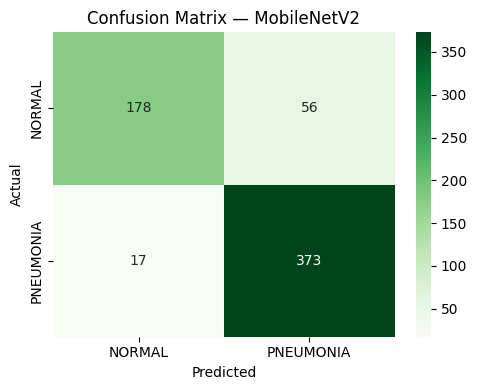

In [9]:
test_gen.reset()
y_true = test_gen.classes
y_prob = model_ft.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('\n── Classification Report ──────────────────────────────────────')
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title('Confusion Matrix — MobileNetV2')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'tl_confusion_matrix.png'), dpi=150)
plt.show()

## 10. Predict on a Single Image

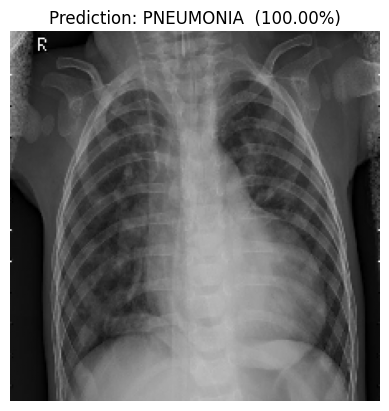

Result → PNEUMONIA  |  Confidence: 100.00%


In [10]:
def predict_single(img_path, threshold=0.5):
    img = load_img(img_path, color_mode='grayscale', target_size=IMAGE_SIZE)
    arr = np.expand_dims(img_to_array(img) / 255.0, axis=0)
    prob  = model_ft.predict(arr, verbose=0)[0][0]
    label = CLASSES[int(prob >= threshold)]
    plt.imshow(img, cmap='gray')
    plt.title(f'Prediction: {label}  ({prob:.2%})', fontsize=12)
    plt.axis('off'); plt.show()
    return label, float(prob)


SAMPLE_IMAGE = os.path.join(TEST_DIR, 'PNEUMONIA',
                             os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0])
label, conf = predict_single(SAMPLE_IMAGE)
print(f'Result → {label}  |  Confidence: {conf:.2%}')

## 11. Save / Load Model

In [11]:
# Best checkpoint already saved by ModelCheckpoint.
# To reload:
# model_ft = tf.keras.models.load_model(MODEL_PATH)
print(f'Best model saved at: {MODEL_PATH}')

Best model saved at: ../models/pneumonia_mobilenetv2.keras
